<a href="https://colab.research.google.com/github/ProductPriceTrackerOrg/data-science/blob/main/notebooks%20/price-forecasing/04_model_building_and_evaluation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Time-series forecasting for historical product price data - 02**

In [1]:
!git clone "https://github.com/ProductPriceTrackerOrg/data-science.git"

Cloning into 'data-science'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 189 (delta 59), reused 91 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 13.94 MiB | 3.75 MiB/s, done.
Resolving deltas: 100% (59/59), done.
Updating files: 100% (42/42), done.


## Import Libraries and Setup

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Define Custom Dataset Class
Description: Create a PyTorch Dataset class to handle the sliding window sequences

In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.FloatTensor(sequences)
        self.targets = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

## Data Loading and Preprocessing
Description: Load the CSV file, normalize data, and create sliding window sequences

In [4]:
camera = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/cameras.csv')
laptop = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/laptops.csv')
mobile = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/mobile-phones.csv')
network_components = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/network-components.csv')
perpherials = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/perpherals.csv')
smart_watches = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/smart-watches.csv')
storage = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/storage.csv')
tablets = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/tablets.csv')
television = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/television.csv')

# Function to process each dataset
def process_dataset(df, category_name):
    df['date'] = pd.to_datetime(df['date'])
    df['category'] = category_name
    df['price'] = df['price'] * 3.4
    print(f"{category_name} - Null values: {df.isnull().sum().sum()}")
    print(f"{category_name} - Shape: {df.shape}")
    return df

# Process all datasets
camera = process_dataset(camera, 'camera')
laptop = process_dataset(laptop, 'laptop')
mobile = process_dataset(mobile, 'mobile')
network_components = process_dataset(network_components, 'network-components')
perpherials = process_dataset(perpherials, 'perpherials')
smart_watches = process_dataset(smart_watches, 'smart-watches')
storage = process_dataset(storage, 'storage')
tablets = process_dataset(tablets, 'tablets')
television = process_dataset(television, 'television')

# Combine all datasets
all_products = pd.concat([camera, laptop, mobile, network_components, perpherials,
                         smart_watches, storage, tablets, television], ignore_index=True)

print(f"Combined dataset shape: {all_products.shape}")
all_products.head()

camera - Null values: 0
camera - Shape: (15090, 5)
laptop - Null values: 0
laptop - Shape: (118708, 5)
mobile - Null values: 0
mobile - Shape: (146876, 5)
network-components - Null values: 0
network-components - Shape: (13078, 5)
perpherials - Null values: 0
perpherials - Shape: (73438, 5)
smart-watches - Null values: 0
smart-watches - Shape: (161966, 5)
storage - Null values: 0
storage - Shape: (267596, 5)
tablets - Null values: 0
tablets - Shape: (60360, 5)
television - Null values: 0
television - Shape: (121726, 5)
Combined dataset shape: (978838, 5)


,title,brand,date,price,category
0,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-01,10196.6,camera
1,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-02,9370.4,camera
2,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-03,10087.8,camera
3,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-04,9214.0,camera
4,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-05,10614.8,camera


In [5]:
import hashlib

# Example DataFrame
df = all_products

# Generate product_id = hex(MD5(title))
df["product_id"] = df["title"].apply(lambda x: hashlib.md5(x.encode("utf-8")).hexdigest())

df.head()

,title,brand,date,price,category,product_id
0,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-01,10196.6,camera,4d88d78e64af738750b78b947b893771
1,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-02,9370.4,camera,4d88d78e64af738750b78b947b893771
2,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-03,10087.8,camera,4d88d78e64af738750b78b947b893771
3,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-04,9214.0,camera,4d88d78e64af738750b78b947b893771
4,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-05,10614.8,camera,4d88d78e64af738750b78b947b893771


In [6]:
df =  df[["product_id","date","price"]]
df.head()

,product_id,date,price
0,4d88d78e64af738750b78b947b893771,2022-11-01,10196.6
1,4d88d78e64af738750b78b947b893771,2022-11-02,9370.4
2,4d88d78e64af738750b78b947b893771,2022-11-03,10087.8
3,4d88d78e64af738750b78b947b893771,2022-11-04,9214.0
4,4d88d78e64af738750b78b947b893771,2022-11-05,10614.8


In [7]:
print(f"Dataset shape: {df.shape}")
print(f"Number of unique products: {df['product_id'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Dataset shape: (978838, 3)
Number of unique products: 869
Date range: 2022-11-01 00:00:00 to 2025-08-02 00:00:00


In [46]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['product_id', 'date'])

# Parameters
SEQUENCE_LENGTH = 90  # 3 months
FORECAST_LENGTH = 7  # 7 days
WINDOW_SIZE = SEQUENCE_LENGTH + FORECAST_LENGTH

def create_sequences_with_per_product_scaling(data, sequence_length, forecast_length):
    """Create sliding window sequences with per-product normalization"""
    all_sequences = []
    all_targets = []
    scalers = {}
    product_indices = []  # Track which product each sequence belongs to

    for product_id in data['product_id'].unique():
        product_data = data[data['product_id'] == product_id]['price'].values.reshape(-1, 1)

        # Skip products with insufficient data
        if len(product_data) < sequence_length + forecast_length:
            continue

        # Create and fit scaler for THIS product only
        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(product_data).flatten()
        scalers[product_id] = scaler

        # Create sliding windows for this product
        for i in range(len(scaled_data) - sequence_length - forecast_length + 1):
            seq = scaled_data[i:i + sequence_length]
            target = scaled_data[i + sequence_length:i + sequence_length + forecast_length]
            all_sequences.append(seq)
            all_targets.append(target)
            product_indices.append(product_id)

    return np.array(all_sequences), np.array(all_targets), scalers, product_indices

print("Creating sequences with per-product scaling...")
X, y, scalers, product_indices = create_sequences_with_per_product_scaling(df, SEQUENCE_LENGTH, FORECAST_LENGTH)
print(f"Total sequences created: {len(X)}")
print(f"Input shape: {X.shape}, Output shape: {y.shape}")
print(f"Number of product scalers: {len(scalers)}")

Creating sequences with per-product scaling...
Total sequences created: 895414
Input shape: (895414, 90), Output shape: (895414, 7)
Number of product scalers: 869


In [47]:
X[0]

array([0.30760499, 0.20204313, 0.24404086, 0.24177072, 0.58342792,
       0.33825199, 0.48240636, 0.45629966, 0.44721907, 0.68671964,
       0.4415437 , 0.1600454 , 0.38933031, 0.08286039, 0.27468785,
       0.20090806, 0.62542565, 0.63677639, 0.19296254, 0.47786606,
       0.3246311 , 0.56526674, 0.54597049, 0.57321226, 0.44494892,
       0.12712826, 0.59023837, 0.13507378, 0.17366629, 0.21906924,
       0.58683314, 0.6322361 , 0.32122588, 0.41089671, 0.584563  ,
       0.6708286 , 0.66515323, 0.20204313, 0.60839955, 0.34846765,
       0.59704881, 0.73212259, 0.23041998, 0.69920545, 0.39727582,
       0.27355278, 0.43019296, 0.4199773 , 0.12826334, 0.72190692,
       0.30874007, 0.66515323, 0.72871737, 0.34279228, 0.72077185,
       0.1169126 , 0.56980704, 0.415437  , 0.73439274, 0.27582293,
       0.37003405, 0.46083995, 0.32009081, 0.74233825, 0.12712826,
       0.61975028, 0.6969353 , 0.12258797, 0.07491487, 0.71396141,
       0.23609535, 0.71623156, 0.35641317, 0.72871737, 0.23950

## Train-Test Split and Data Normalization
Description: Split data chronologically and normalize using training data only

In [48]:
# Chronological split (80% train, 20% test)
split_idx = int(0.9 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
product_indices_train = product_indices[:split_idx]
product_indices_test = product_indices[split_idx:]

print(f"Training sequences: {len(X_train)}")
print(f"Testing sequences: {len(X_test)}")

# Create DataLoaders (data is already scaled per-product)
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Data preprocessing completed!")

Training sequences: 805872
Testing sequences: 89542
Data preprocessing completed!


## LSTM Seq2Seq Model Implementation
Description: Define the LSTM-based encoder-decoder architecture

In [49]:
class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=1, forecast_length=7):
        super(LSTMSeq2Seq, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.forecast_length = forecast_length

        # Encoder
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Decoder
        self.decoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Output layer
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, src):
        batch_size = src.size(0)

        # Encode
        src = src.unsqueeze(-1)  # Add feature dimension
        encoder_out, (hidden, cell) = self.encoder(src)

        # Decode
        decoder_input = src[:, -1:, :]  # Use last input as first decoder input
        outputs = []

        for _ in range(self.forecast_length):
            decoder_out, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            output = self.linear(decoder_out)
            outputs.append(output)
            decoder_input = output  # Use prediction as next input

        return torch.cat(outputs, dim=1).squeeze(-1)

# Initialize LSTM model
lstm_model = LSTMSeq2Seq().to(device)
print(f"LSTM Model parameters: {sum(p.numel() for p in lstm_model.parameters())}")

LSTM Model parameters: 398465


## Transformer Components Implementation
Description: Implement positional encoding and Transformer-based Seq2Seq model

In [35]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_length=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_length, d_model)
        position = torch.arange(0, max_length).unsqueeze(1).float()

        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                           -(np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerSeq2Seq(nn.Module):
    def __init__(self, input_size=1, d_model=128, nhead=8, num_encoder_layers=3,
                 num_decoder_layers=3, forecast_length=7):
        super(TransformerSeq2Seq, self).__init__()
        self.d_model = d_model
        self.forecast_length = forecast_length

        # Input projection
        self.input_projection = nn.Linear(input_size, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            batch_first=True
        )

        # Output projection
        self.output_projection = nn.Linear(d_model, input_size)

    def generate_square_subsequent_mask(self, sz):
        """Generate causal mask for decoder"""
        mask = torch.triu(torch.ones(sz, sz), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, src):
        batch_size = src.size(0)

        # Prepare source
        src = src.unsqueeze(-1)  # Add feature dimension
        src = self.input_projection(src) * np.sqrt(self.d_model)
        src = self.pos_encoder(src)

        # Prepare target (start with zeros, will be filled iteratively)
        tgt = torch.zeros(batch_size, self.forecast_length, self.d_model).to(src.device)

        # Generate causal mask
        tgt_mask = self.generate_square_subsequent_mask(self.forecast_length).to(src.device)

        # Transformer forward pass
        output = self.transformer(src, tgt, tgt_mask=tgt_mask)

        # Project to output dimension
        output = self.output_projection(output)

        return output.squeeze(-1)

# Initialize Transformer model
transformer_model = TransformerSeq2Seq().to(device)
print(f"Transformer Model parameters: {sum(p.numel() for p in transformer_model.parameters())}")

Transformer Model parameters: 3757953


## Training Function
Description: Implement the training loop for both models

In [50]:
def train_model(model, train_loader, num_epochs=50, learning_rate=0.001):
    """Train the model and return loss history"""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    loss_history = []

    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

        if (epoch + 1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

    return loss_history

## **Evaluation** Function
Description: Implement evaluation metrics (MAE and RMSE) calculation

In [51]:
def evaluate_model(model, test_loader, scalers, product_indices_test):
    """Evaluate model with per-product inverse transformation"""
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        batch_start_idx = 0
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Move to CPU and convert to numpy
            pred_np = output.cpu().numpy()
            target_np = target.cpu().numpy()

            # Process each sample in the batch with its corresponding scaler
            batch_size = pred_np.shape[0]
            for i in range(batch_size):
                sample_idx = batch_start_idx + i
                if sample_idx >= len(product_indices_test):
                    break

                product_id = product_indices_test[sample_idx]
                scaler = scalers[product_id]

                # Inverse transform using the correct product's scaler
                pred_original = scaler.inverse_transform(pred_np[i].reshape(-1, 1)).flatten()
                actual_original = scaler.inverse_transform(target_np[i].reshape(-1, 1)).flatten()

                predictions.append(pred_original)
                actuals.append(actual_original)

            batch_start_idx += batch_size

    # Convert to numpy arrays
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    # print(f"Predictions shape: {predictions}, Actuals shape: {actuals}")

    # Calculate metrics
    mae = mean_absolute_error(actuals.flatten(), predictions.flatten())
    rmse = np.sqrt(mean_squared_error(actuals.flatten(), predictions.flatten()))

    return mae, rmse, predictions, actuals

In [57]:
def plot_predictions(X_test_sample, y_test_actual, y_test_predicted, scalers, product_indices_test, num_samples=3):
    """Plot sample predictions vs actual values with proper input/output separation"""
    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = [axes]

    for i in range(min(num_samples, len(X_test_sample))):
        # Get the product ID for this sample
        product_id = product_indices_test[i]
        scaler = scalers[product_id]

        # Inverse transform to original scale
        input_history = scaler.inverse_transform(X_test_sample[i].reshape(-1, 1)).flatten()
        actual_future = y_test_actual[i].reshape(-1, 1).flatten()
        predicted_future = y_test_predicted[i].reshape(-1, 1).flatten()
        # print(f"Product ID: {product_id}")
        # print(f"Input History: {input_history}")
        # print(f"Actual Future y_test_actual: {y_test_actual[i].reshape(-1, 1)}")
        # print(f"Predicted Future y_test_predicted: {y_test_predicted[i].reshape(-1, 1)}")
        # print(f"Actual Future: {actual_future}")
        # print(f"Predicted Future: {predicted_future}")

        # Create x-axis
        historical_x = range(1, 91)  # 90 historical points
        forecast_x = range(91, 98)   # 7 forecast points

        axes[i].plot(historical_x, input_history, 'b-', label='Input History (30 days)', linewidth=2)
        axes[i].plot(forecast_x, actual_future, 'g-', label='Actual Future (7 days)', linewidth=2, marker='o')
        axes[i].plot(forecast_x, predicted_future, 'r--', label='Predicted Future (7 days)', linewidth=2, marker='s')

        axes[i].set_title(f'Sample {i+1}: Price Forecast (Product ID: {product_id})')
        axes[i].set_xlabel('Time Steps')
        axes[i].set_ylabel('Price')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].axvline(x=30.5, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')

    plt.tight_layout()
    plt.show()

## Train LSTM Model
Description: Train the LSTM model and track training progress

Training LSTM Model...
Epoch [1/10], Loss: 0.040781
Epoch [2/10], Loss: 0.038900
Epoch [3/10], Loss: 0.038755
Epoch [4/10], Loss: 0.038610
Epoch [5/10], Loss: 0.038561
Epoch [6/10], Loss: 0.038534
Epoch [7/10], Loss: 0.038419
Epoch [8/10], Loss: 0.038384
Epoch [9/10], Loss: 0.038535
Epoch [10/10], Loss: 0.038712


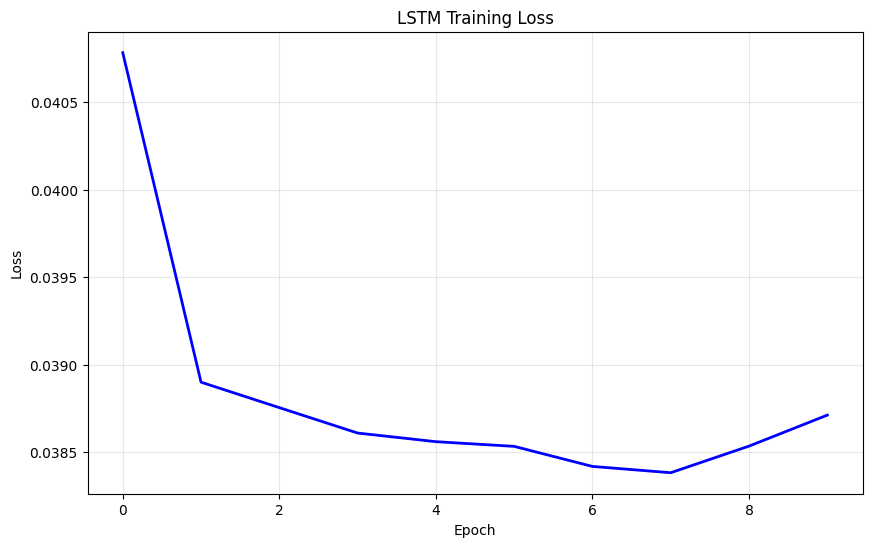

LSTM training completed!


In [53]:
print("Training LSTM Model...")
print("="*50)

# Train LSTM
lstm_loss_history = train_model(lstm_model, train_loader, num_epochs=10, learning_rate=0.001)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(lstm_loss_history, 'b-', linewidth=2)
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print("LSTM training completed!")

## Train Transformer Model
Description: Train the Transformer model and track training progress

Training Transformer Model...
Epoch [1/5], Loss: 0.042630
Epoch [2/5], Loss: 0.039926
Epoch [3/5], Loss: 0.039465
Epoch [4/5], Loss: 0.039262
Epoch [5/5], Loss: 0.039685


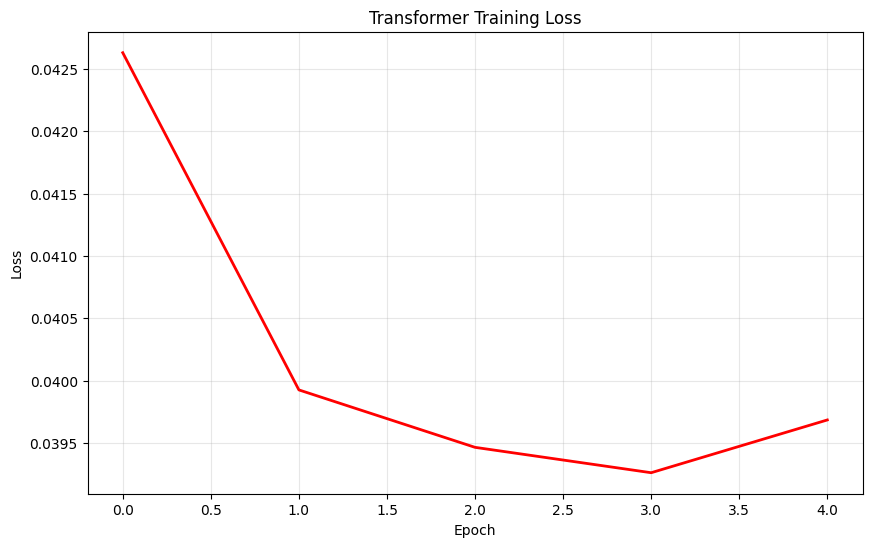

Transformer training completed!


In [19]:
print("Training Transformer Model...")
print("="*50)

# Train Transformer
transformer_loss_history = train_model(transformer_model, train_loader, num_epochs=5, learning_rate=0.001)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(transformer_loss_history, 'r-', linewidth=2)
plt.title('Transformer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print("Transformer training completed!")


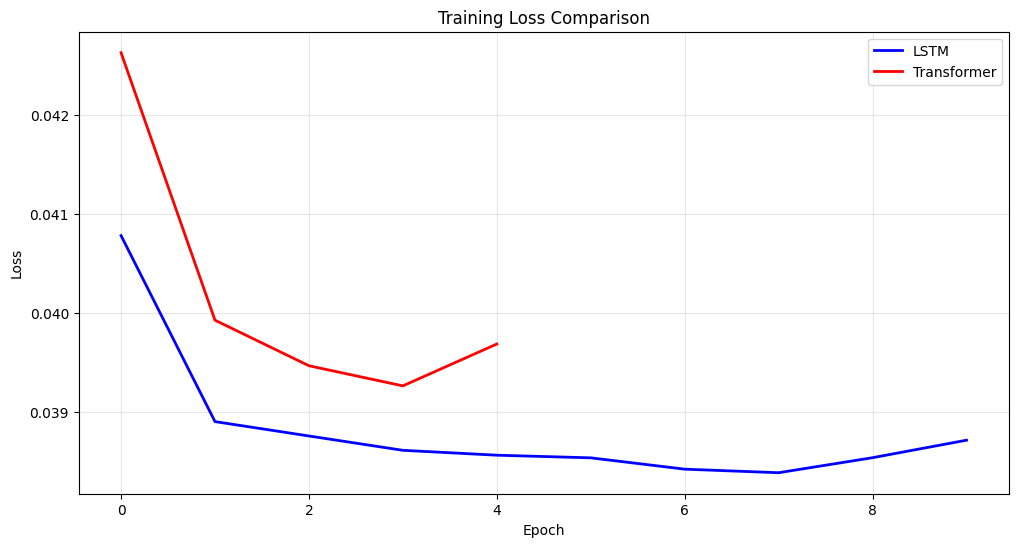

In [55]:
# Compare training curves
plt.figure(figsize=(12, 6))
plt.plot(lstm_loss_history, 'b-', label='LSTM', linewidth=2)
plt.plot(transformer_loss_history, 'r-', label='Transformer', linewidth=2)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Evaluate Models

Evaluating LSTM Model...
LSTM Results:
MAE: 1851.7007
RMSE: 3717.8176

LSTM Prediction Samples:


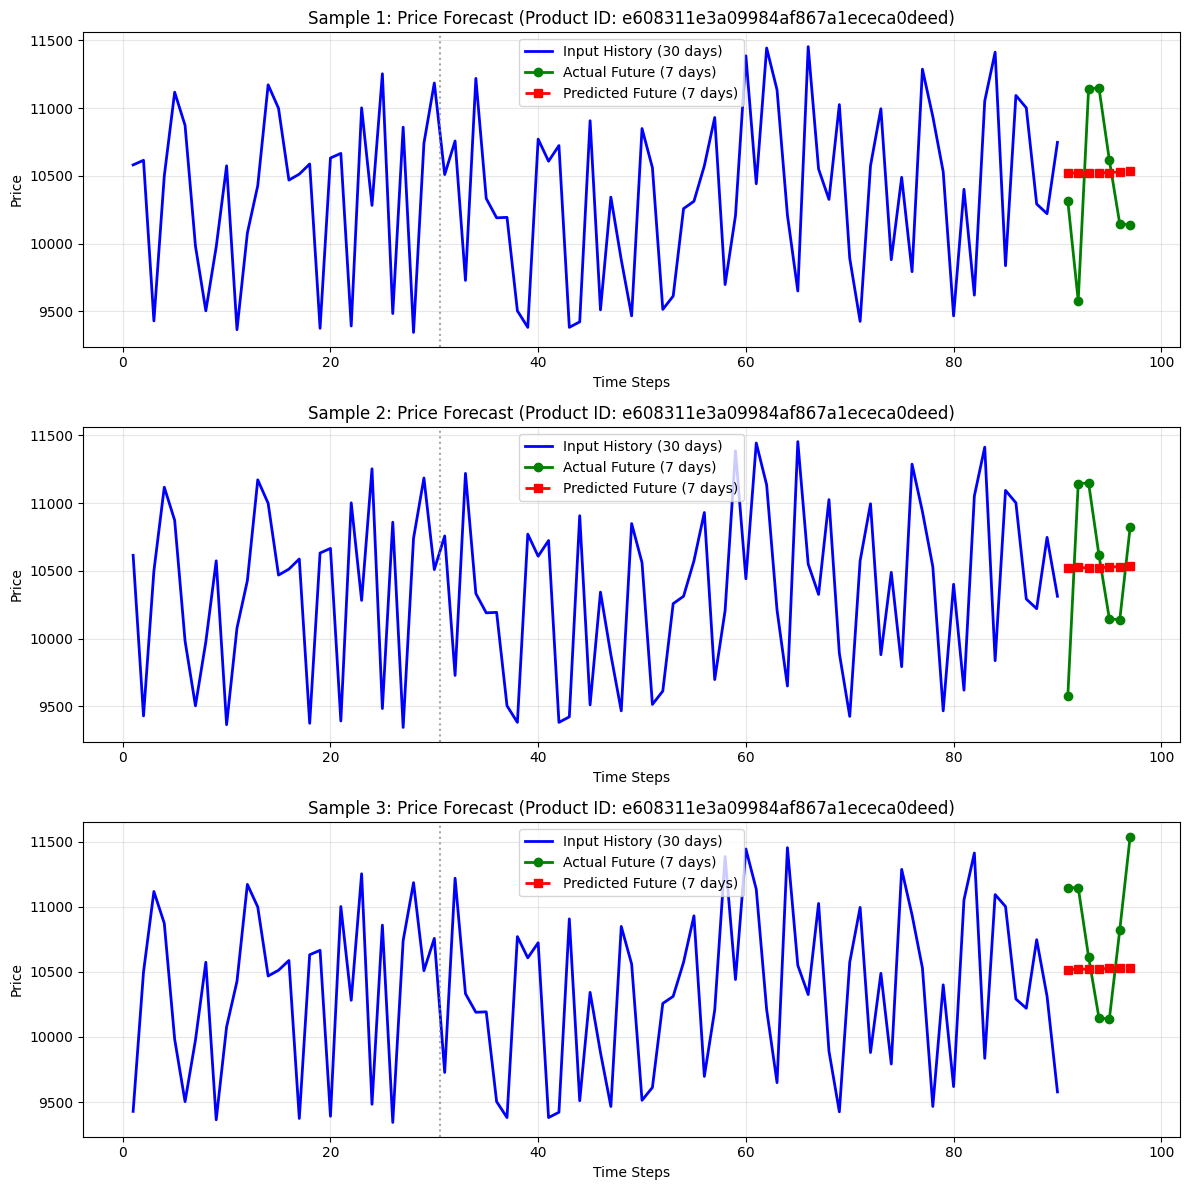

In [58]:
print("Evaluating LSTM Model...")
print("="*40)

lstm_mae, lstm_rmse, lstm_pred, lstm_actual = evaluate_model(lstm_model, test_loader, scalers, product_indices_test)

print(f"LSTM Results:")
print(f"MAE: {lstm_mae:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")

# Plot LSTM predictions with proper input/output separation
print("\nLSTM Prediction Samples:")
plot_predictions(X_test, lstm_actual, lstm_pred, scalers, product_indices_test, num_samples=3)

Evaluating Transformer Model...
Transformer Results:
MAE: 10764.2998
RMSE: 18887.7357

Transformer Prediction Samples:


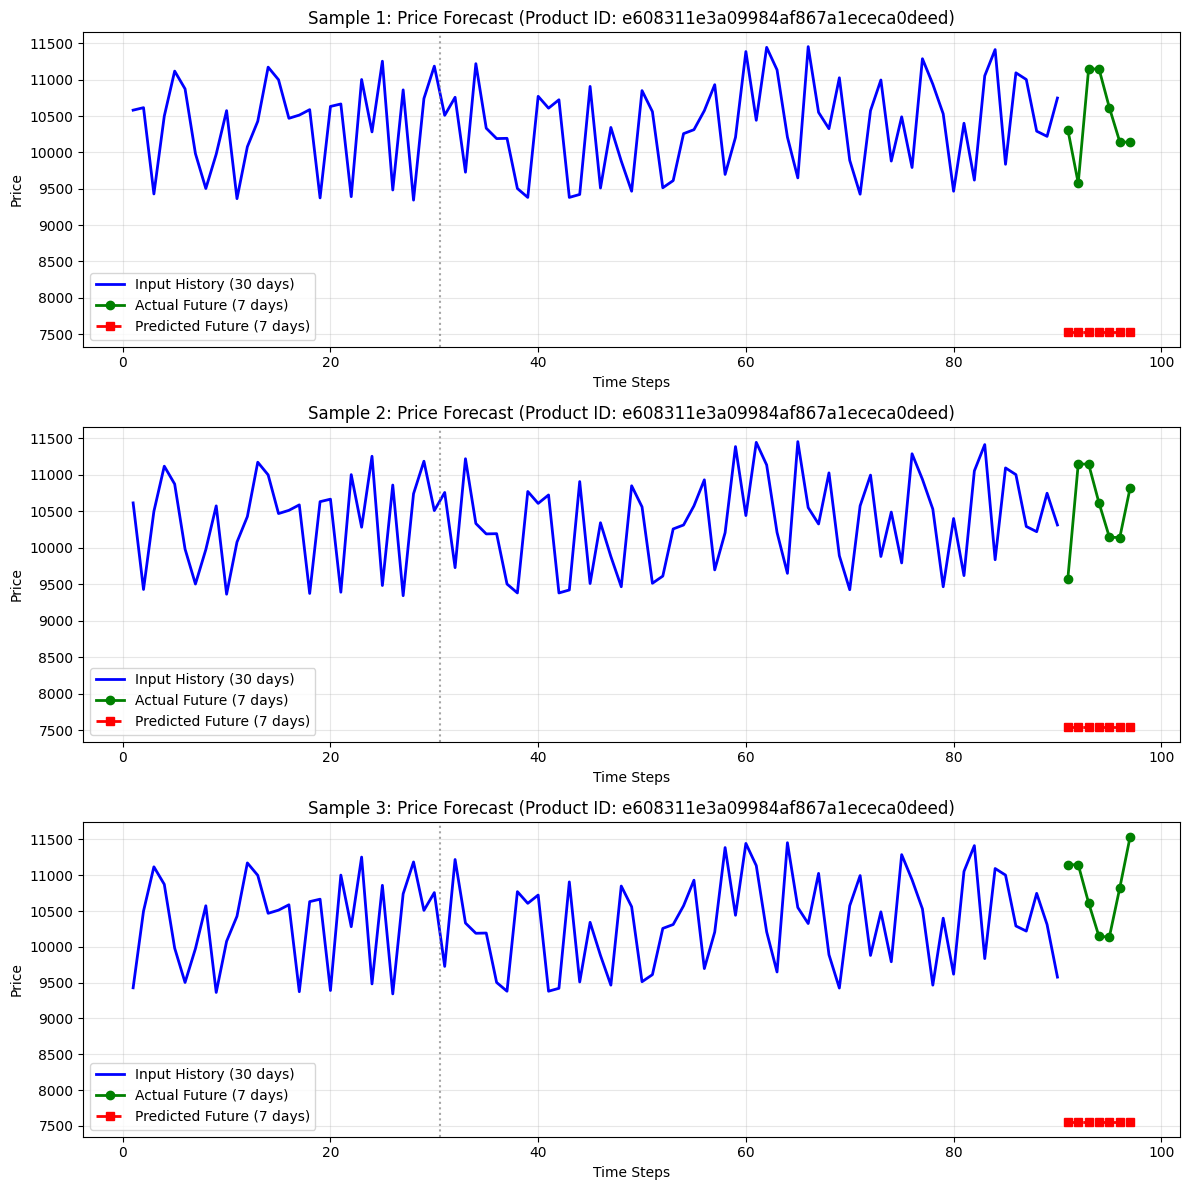

In [59]:
print("Evaluating Transformer Model...")
print("="*40)

transformer_mae, transformer_rmse, transformer_pred, transformer_actual = evaluate_model(transformer_model, test_loader, scalers, product_indices_test)

print(f"Transformer Results:")
print(f"MAE: {transformer_mae:.4f}")
print(f"RMSE: {transformer_rmse:.4f}")

# Plot Transformer predictions with proper input/output separation
print("\nTransformer Prediction Samples:")
plot_predictions(X_test, transformer_actual, transformer_pred, scalers, product_indices_test, num_samples=3)

FINAL MODEL COMPARISON
      Model          MAE         RMSE
       LSTM  1851.700684  3717.817639
Transformer 10764.299805 18887.735703

LSTM model performs better (lower MAE)


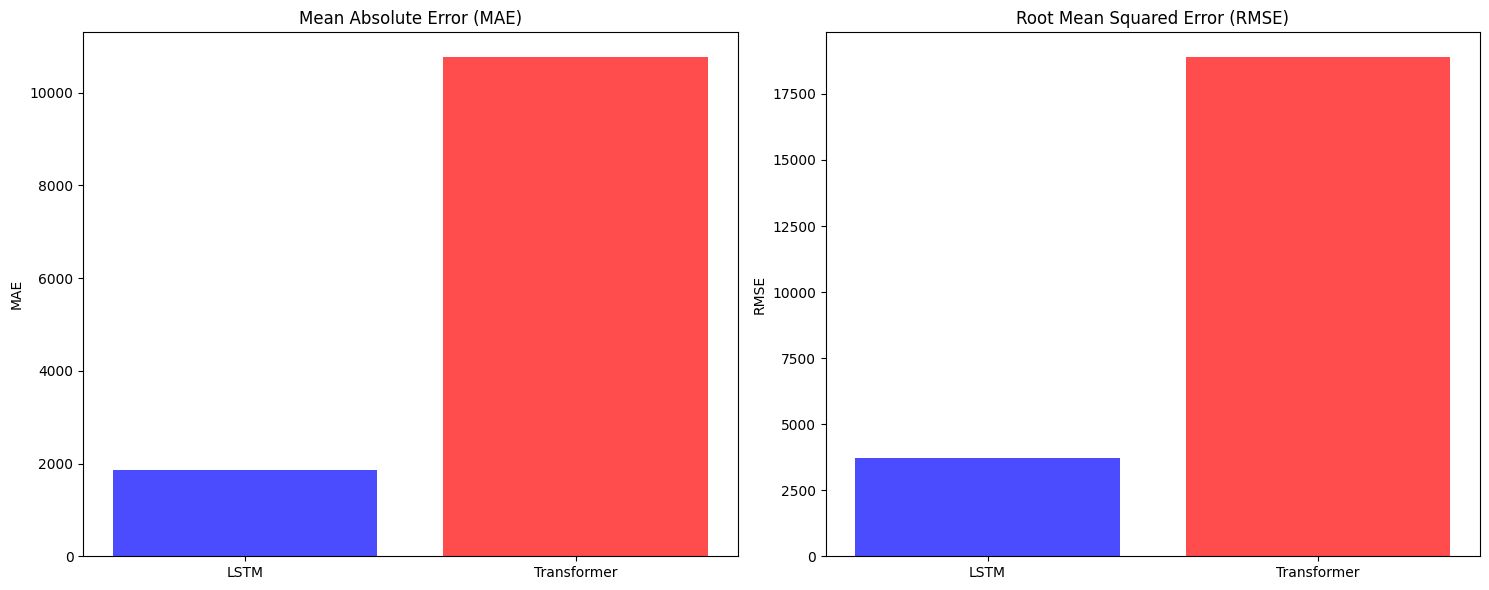

In [60]:
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

results_df = pd.DataFrame({
    'Model': ['LSTM', 'Transformer'],
    'MAE': [lstm_mae, transformer_mae],
    'RMSE': [lstm_rmse, transformer_rmse]
})

print(results_df.to_string(index=False))
print()

# Determine best model
if lstm_mae < transformer_mae:
    print("LSTM model performs better (lower MAE)")
else:
    print("Transformer model performs better (lower MAE)")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

models = ['LSTM', 'Transformer']
maes = [lstm_mae, transformer_mae]
rmses = [lstm_rmse, transformer_rmse]

ax1.bar(models, maes, color=['blue', 'red'], alpha=0.7)
ax1.set_title('Mean Absolute Error (MAE)')
ax1.set_ylabel('MAE')

ax2.bar(models, rmses, color=['blue', 'red'], alpha=0.7)
ax2.set_title('Root Mean Squared Error (RMSE)')
ax2.set_ylabel('RMSE')

plt.tight_layout()
plt.show()

## Save Models and Scaler
Description: Save trained models and the fitted scaler for future use

In [ ]:
# Save models
torch.save(lstm_model.state_dict(), 'lstm_forecaster.pth')
torch.save(transformer_model.state_dict(), 'transformer_forecaster.pth')

# Save all product scalers
with open('product_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print("Models and scalers saved successfully!")
print("Files created:")
print("- lstm_forecaster.pth")
print("- transformer_forecaster.pth")
print(f"- product_scalers.pkl (contains {len(scalers)} individual scalers)")

In [ ]:
# Example of how to load and use saved models
def load_models():
    """Load saved models and scaler"""

    # Load scaler
    with open('price_scaler.pkl', 'rb') as f:
        loaded_scaler = pickle.load(f)

    # Load LSTM model
    loaded_lstm = LSTMSeq2Seq().to(device)
    loaded_lstm.load_state_dict(torch.load('lstm_forecaster.pth'))
    loaded_lstm.eval()

    # Load Transformer model
    loaded_transformer = TransformerSeq2Seq().to(device)
    loaded_transformer.load_state_dict(torch.load('transformer_forecaster.pth'))
    loaded_transformer.eval()

    return loaded_lstm, loaded_transformer, loaded_scaler

print("Model loading function defined.")
print("Use load_models() to reload saved models for inference.")